# Project 1 Widgets

This notebook contains some 'widgets' - in other words, code snippets - that demonstrate how to create graphs and analyze data for Project 1. You are welcome to take the code from these widgets and modify it for your own project. Note: Some of the things that apply to my data set may not apply to yours.

## Widget 1

Import libraries, load data into pandas dataframe, clean column names, etc.

In [129]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import datetime as dt
from matplotlib.ticker import MaxNLocator

file = 'data.csv'

# Load data into pandas dataframe
df = pd.read_csv(file)

# Rename columns
df.columns = ['Time', 'Temp (deg C)', 'Pressure (mbar)', 'Humidity (%)', 'Altitude (m)']

# Drop altitude - we don't need it for this project
df.drop(columns=['Altitude (m)'], inplace=True)

# Get ride of decimal part of time - this level of detail is not needed
df['Time'] = df['Time'].str.split(".").str.get(0)

# Choose start and end indices (in case you want to discard some of the data at the start/end
start_id = 1485
end_id = len(df)



# Copy the dataframe into a new dataframe with the slice you are interested in
hourly = df[start_id:end_id].copy()
hourly.reset_index(drop=True, inplace=True)

# This is because my data crosses over the time change on 3/7 to 3/8. I interpolated for the missing hour
# You probably don't need these two lines
hourly=pd.concat([hourly[:108], hourly[108:109], hourly[108:]]).reset_index()
hourly.loc[108, 'Time'] = "2026-03-08 02:00:03"

# Check what we have in the DF
hourly

,index,Time,Temp (deg C),Pressure (mbar),Humidity (%)
0,0,2026-03-03 14:00:03,17.579883,837.824342,49.679045
1,1,2026-03-03 15:00:03,17.464453,838.439740,49.837575
2,2,2026-03-03 16:00:03,17.333984,838.692798,50.393257
3,3,2026-03-03 17:00:03,20.511133,839.136942,44.970206
4,4,2026-03-03 18:00:03,24.340820,839.986558,39.299749
...,...,...,...,...,...
160,159,2026-03-10 06:00:03,9.469531,828.620698,45.862787
161,160,2026-03-10 07:00:03,9.489453,828.522053,46.843126
162,161,2026-03-10 08:00:03,9.680273,828.644477,45.674169
163,162,2026-03-10 09:00:03,10.889648,828.586949,46.000780


## Widget 2

Generate summary statistics for sensor readings for the time period measured.

`hourly.describe()` gives you everything you need, including 5-number summary.

In [130]:
# Summary stats for sensor readings
hourly.describe()

,index,Temp (deg C),Pressure (mbar),Humidity (%)
count,165.000000,165.000000,165.000000,165.000000
mean,81.660606,11.746649,832.191470,51.505290
std,47.386771,6.605893,4.978696,14.768253
min,0.000000,-2.242969,820.459654,25.859860
25%,41.000000,6.388086,828.802180,41.767581
50%,82.000000,10.889648,830.741347,48.893430
75%,122.000000,17.524609,836.456842,58.721411
max,163.000000,25.580664,841.388034,82.756708


## Widget 3

Plot line graph showing one of the sensor readings over time. Remember you will need to do this for each quantity (temp, pressure, humidity) and provide a commentary.

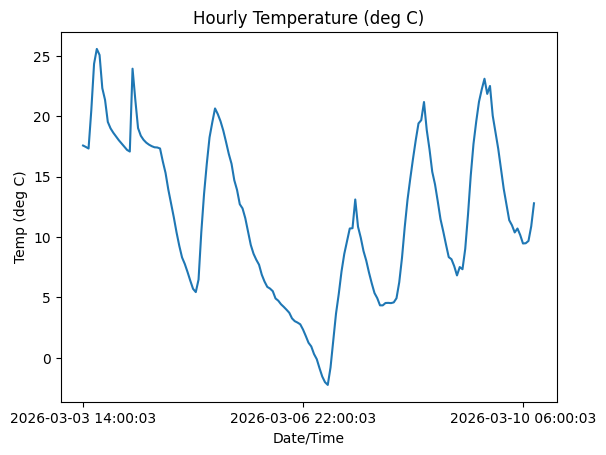

In [90]:
# Set up figure and axes using matplotlib.pyplot as plt
fig, ax = plt.subplots()

ax.plot(hourly['Time'], hourly['Temp (deg C)'])

# Set the maximum number of major ticks to 3 - adjust this number so that x axis labels don't overlap
ax.xaxis.set_major_locator(MaxNLocator(3))

# Set up title and axis labels and plot graph
plt.title("Hourly Temperature (deg C)")
plt.ylabel("Temp (deg C)")
plt.xlabel("Date/Time")
plt.show()

## Widget 4

Get comparable data from meteostat and store in a `pandas` dataframe.

Note: We will use Denver International Airport (DIA) weather data as this is the most up to date. The station code is 72565.

In [91]:
import meteostat as ms

# Check data availability for a station
station = '72565'  # Toronto Pearson International Airport

inventory = ms.stations.inventory(station)

print(f"Data available from {inventory.start} to {inventory.end}.")
print(f"Available parameters: {inventory.parameters}")

Data available from 1994-07-18 to 2026-03-17.
Available parameters: [<Parameter.PRCP: 'prcp'>, <Parameter.PRES: 'pres'>, <Parameter.TEMP: 'temp'>, <Parameter.TMAX: 'tmax'>, <Parameter.TMIN: 'tmin'>, <Parameter.TXMN: 'txmn'>, <Parameter.TXMX: 'txmx'>, <Parameter.CLDC: 'cldc'>, <Parameter.COCO: 'coco'>, <Parameter.RHUM: 'rhum'>, <Parameter.WDIR: 'wdir'>, <Parameter.WSPD: 'wspd'>, <Parameter.SNWD: 'snwd'>, <Parameter.TSUN: 'tsun'>, <Parameter.WPGT: 'wpgt'>]


In [121]:
# Set start and end dates to be start and end of your hourly sensor readings

start= dt.datetime.strptime(hourly['Time'].iloc[0], "%Y-%m-%d %H:%M:%S") 
end = dt.datetime.strptime(hourly['Time'].iloc[-1], "%Y-%m-%d %H:%M:%S") + dt.timedelta(hours=1)

# Select Station - Use Denver International Airport as other stations may not have recent hourly data yet
DIA_stn = ms.Station(id=station)

#Get data
DIA_data = ms.hourly(DIA_stn, start, end)

# Store data in pandas dataframes
dia = DIA_data.fetch()
dia = dia.reset_index()
dia['time'] = dia['time'].astype('string')
dia

,time,temp,rhum,prcp,snwd,wdir,wspd,wpgt,pres,tsun,cldc,coco
0,2026-03-03 15:00:00,7.0,71,<NA>,<NA>,330,7.0,<NA>,1018.0,<NA>,6,3
1,2026-03-03 16:00:00,7.0,76,0.0,<NA>,360,17.0,<NA>,1018.0,<NA>,4,3
2,2026-03-03 17:00:00,6.0,82,0.0,<NA>,340,15.0,<NA>,1020.0,<NA>,6,7
3,2026-03-03 18:00:00,4.0,93,0.1,<NA>,40,15.0,<NA>,1020.0,<NA>,2,7
4,2026-03-03 19:00:00,7.0,82,0.0,<NA>,30,17.0,<NA>,1020.0,<NA>,2,7
...,...,...,...,...,...,...,...,...,...,...,...,...
160,2026-03-10 07:00:00,9.6,29,<NA>,<NA>,225,18.5,<NA>,1003.4,<NA>,2,2
161,2026-03-10 08:00:00,8.8,31,<NA>,<NA>,222,18.5,<NA>,1003.2,<NA>,2,2
162,2026-03-10 09:00:00,8.4,31,<NA>,<NA>,221,18.5,<NA>,1003.7,<NA>,3,2
163,2026-03-10 10:00:00,7.9,32,<NA>,<NA>,218,20.4,<NA>,1003.8,<NA>,3,2


## Widget 5

Plot your sensor readings against the DIA data. You will need to do this for each sensor measurement (temp, pressure, humidity).

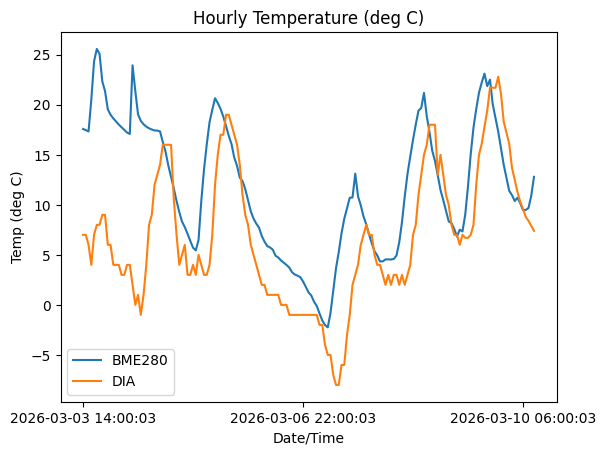

In [122]:
# Set up figure and axes using matplotlib.pyplot as plt
fig, ax = plt.subplots()

ax.plot(hourly['Time'], hourly['Temp (deg C)'], label='BME280')
ax.plot(hourly['Time'], dia['temp'], label='DIA')
ax.legend()
# Set the maximum number of major ticks to 3 - adjust this number so that x axis labels don't overlap
ax.xaxis.set_major_locator(MaxNLocator(3))

# Set up title and axis labels and plot graph
plt.title("Hourly Temperature (deg C)")
plt.ylabel("Temp (deg C)")
plt.xlabel("Date/Time")
plt.show()

## Widget 6

Side-by-side Box plots. You will need to do this for each sensor reading (temp, pressure, humidity).

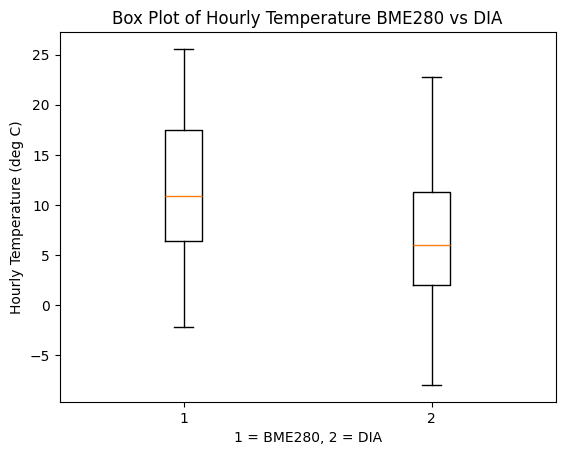

In [128]:
# Create a combined plot for temperature for bme280 sensor and DIA
fig, ax = plt.subplots()

ax.boxplot([hourly['Temp (deg C)'], dia['temp']])
plt.xlabel("1 = BME280, 2 = DIA")
plt.ylabel("Hourly Temperature (deg C)")
plt.title("Box Plot of Hourly Temperature BME280 vs DIA")

plt.show()

## Widget 7

Scatter plot. We will plot BME280 temperature readings versus DIA readings. You will need to do this for each sensor measurement (temperature, pressure, humidity).

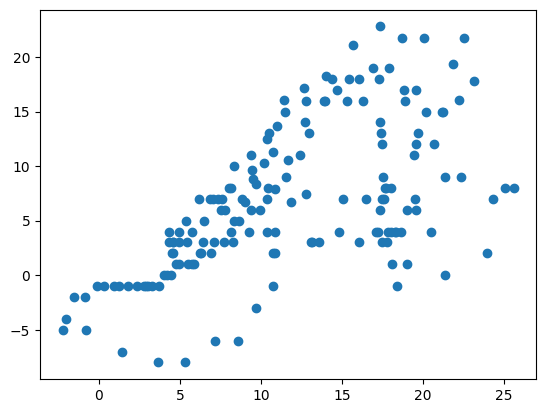

In [132]:
x = hourly['Temp (deg C)']
y = dia['temp']
plt.scatter(x, y)
plt.show()

In [133]:
from scipy import stats

slope, intercept, r, p, std_err = stats.linregress(x, y)
print(f"slope: {slope:.3f}")
print(f"intercept: {intercept:.3f}")
print(f"r: {r:.3f}")

slope: 0.625
intercept: -0.557
r: 0.605


In [ ]:
def predict(x):
  return slope * x + intercept
    
model_data = list(map(predict, x))
plt.plot(x, model_data)
plt.scatter(x, y)
plt.xlabel("Goals scored")
plt.ylabel("Goals conceded")
plt.title("Goals scored vs goals conceded by team, EPL 2024-25")
plt.show()